# Домашнее задание 2. Расчёт коэффициента сверхсжимаемости газа

## Введение

В пластовых условиях реальный газ отклоняется от идеального. Степень этого отклонения описывается **коэффициентом сверхсжимаемости** (Z-фактор, *compressibility factor*).

> **Z = 1** — газ ведёт себя как идеальный;  
> **Z ≠ 1** — наблюдается отклонение от идеального поведения.

Подробнее о Z-факторе можно прочитать в [Википедии](https://en.wikipedia.org/wiki/Compressibility_factor).

## Справочный документ

Расчёт выполняется по **ГОСТ 30319.2-96** — скачайте документ по [этой ссылке](https://files.stroyinf.ru/Data/187/18729.pdf). Вам понадобится **раздел 3.2.3** (модифицированное уравнение состояния GERG-91 мод., стр. 7). Проверить себя можно на стр. 48

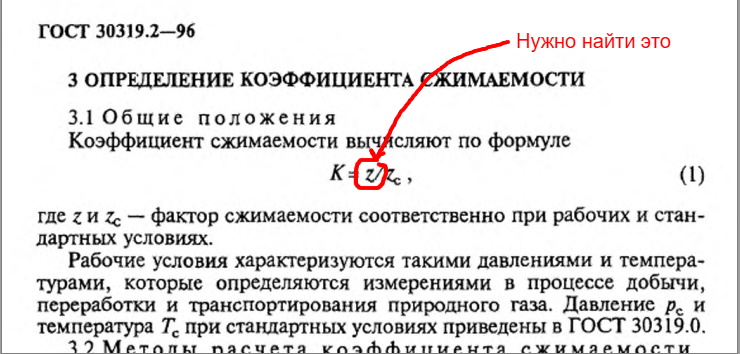

## Задание

### Что нужно сделать

1. **Реализовать метод `Fluid.get_Z(P, T)`** — расчёт коэффициента сверхсжимаемости газа по методике **GERG-91 мод.** (ГОСТ 30319.2, раздел 3.2.3, стр. 7).

2. **Реализовать метод `Fluid.get_Bg(P, T)`** — расчёт объёмного коэффициента расширения газа ([что это?](https://ru.wikipedia.org/wiki/Объёмный_фактор)):

3. **Реализовать методы `Fluid.plot_Z()` и `Fluid.plot_Bg()`** — построить графики зависимостей $Z(P)$ и $B_g(P)$ при фиксированной температуре.

4. **Загрузить свои индивидуальные данные** из файла `hw2_data.csv` (разделитель `;`), найти свою строку и использовать параметры `xa`, `xy`, `rho_c` для инициализации класса `Fluid`.

### Исходные данные

| Параметр | Описание | Единицы |
|----------|----------|---------|
| `rho_c` | Плотность газа в стандартных условиях | кг/м³ |
| `xa` | Мольная доля азота (N₂) | мол. доля |
| `xy` | Мольная доля диоксида углерода (CO₂) | мол. доля |

### Формат сдачи

- Заполненный ноутбук с рабочим кодом и построенными графиками.

> **Внимание!** Обратите внимание на единицы измерения в ГОСТе и конвертируйте при необходимости.

---

## Шаблон класса `Fluid`

Ниже приведён каркас класса. Вам нужно **дописать тела методов** `get_Z` и `get_Bg`, а также реализовать построение графиков в `plot_Z` и `plot_Bg`.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


class Fluid:
    
    Pstd = 1
    Tstd = 293.15
    
    def __init__(self, rho_c: float, xa: float, xy: float):
        
        self.rho_c = rho_c
        self.xa = xa / 100
        self.xy = xy / 100
        self.xe = 1 - xa - xy
        self.zstd = 1 - (0.0741 * rho_c - 0.006 - 0.063 * xa - 0.0575 * xy)**2
        self.Me = (24.05525 * self.zstd * rho_c - 28.0135 * xa - 44.01 * xy)/self.xe
        self.H = 128.64 + 47.479 * self.Me
        
    def get_Z(self, P: float, T: float) -> float:

        B1 = -0.425468 + 2.865 * 10**(-3) * T - 4.62073 * 10**(-6) * T**2 + (8.77118 * 10**(-4) - 5.56281 * 10**(-6) * T + 8.8151 * 10**(-9) * T**2) * self.H + (-8.24747 * 10**(-7) + 4.31436 * 10**(-9) * T - 6.08319 * 10**(-12) * T**2) * self.H**2
        B2 = -0.1446 + 7.4091 * 10**(-4) * T - 9.1195 * 10**(-7) * T**2
        B23 = -0.339693 + 1.61176 * 10**(-3) * T - 2.04429 * 10**(-6) * T**2
        B3 = -0.86834 + 4.0376 * 10**(-3) * T - 5.1657 * 10**(-6) * T**2
        C1 = -0.302488 + 1.95861 * 10**(-3) * T - 3.16302 * 10**(-6) * T**2 + (6.46422 * 10**(-4) - 4.22876 * 10**(-6) * T + 6.88157 * 10**(-9) * T**2) * self.H + (-3.32805 * 10**(-7) + 2.2316 * 10**(-9) * T - 3.67713 * 10**(-12) * T**2) * self.H**2
        C2 = 7.8498 * 10**(-3) - 3.9895 * 10**(-5) * T + 6.1187 * 10**(-8) * T**2
        C3 = 2.0513 * 10**(-3) + 3.4888 * 10**(-5) * T - 8.3703 * 10**(-8) * T**2
        C223 = 5.52066 * 10**(-3) - 1.68609 * 10**(-5) * T + 1.57169 * 10**(-8) * T**2
        C233 = 3.58783 * 10**(-3) + 8.06674 * 10**(-6) * T - 3.25798 * 10**(-8) * T**2
        B = 0.72 + 1.875 * 10**(-5) * (320 - T)**2
        C = 0.92 + 0.0013 * (T-270)
        Bm = self.xe**2 * B1 + self.xe * self.xa * B * (B1 + B2) - 1.73 * self.xe * self.xy * (B1 * B3)**0.5 + self.xa**2 * B2 + 2 * self.xa * self.xy * B23 + self.xy**2 * B3
        Cm = self.xe**3 * C1 + 3 * self.xe**2 * self.xa * C * (C1**2 * C2)**(1/3) + 2.76 * self.xe**2 * self.xy * (C1**2 * C3)**(1/3) + 3 * self.xe * self.xa**2 * C * (C1 * C2**2)**(1/3) + 6.6 * self.xe * self.xa * self.xy * (C1 * C2 * C3)**(1/3) + 2.76 * self.xe * self.xy**2 * (C1 * C3**2)**(1/3) + self.xa**3 * C2 + 3 * self.xa**2 * self.xy * C223 + 3 * self.xa * self.xy**2 * C233 + self.xy**3 * C3
        b = (10**3 * P / 10)/(2.7715 * T)
        B0 = b * Bm
        C0 = b**2 * Cm
        A1 = 1 + B0
        A0 = 1 + 1.5 * (B0 + C0)
        A2 = (A0 + (A0**2 - A1**3)**0.5)**(1/3)
        z = (1 + A2 + A1/A2)/3
        return z
        
    def get_Bg(self, P: float, T: float) -> float:

        z = self.get_Z(P, T)
        Bg = (self.Pstd * z * T) / (P * self.Tstd)
        return Bg
        
    def plot_Z(self, T_fixed = 310):
        
        import matplotlib.pyplot as plt
        import numpy as np
        Ps = list(range(1, 100))
        z = []
        for i in Ps:
            z.append(self.get_Z(i, T_fixed))
        fig, ax = plt.subplots()
        ax.grid()
        ax.set_xlabel('p, atm')
        ax.set_ylabel('z')
        plt.plot(Ps, z)
    
    def plot_Bg(self, T_fixed = 310):
        
        import matplotlib.pyplot as plt
        import numpy as np
        Ps = list(range(1, 100))
        bgs = []
        for i in Ps:
            bgs.append(self.get_Bg(i, T_fixed))
        fig, ax = plt.subplots()
        ax.grid()
        ax.set_xlabel('p, atm')
        ax.set_ylabel('bg')
        plt.plot(Ps, bgs)

---

## Загрузка данных и проверка

Загрузите файл `hw2_data.csv`, найдите свою строку и создайте объект `Fluid` с вашими параметрами. Затем вызовите методы для проверки.

,student,"xa, mol. %","xy, mol. %","rho_c, kg/m3"
0,Али Иван,0.3745,0.9507,0.6799
1,Альзейн Мохаммад Альжавад,0.7320,0.5987,0.6799
2,Андреев Вячеслав Олегович,0.1560,0.1560,0.6799
3,Гедымин Герман Константинович,0.0581,0.8662,0.6799
4,Инюхин Дмитрий Романович,0.6011,0.7081,0.6799
5,Котиев Муслим Магометович,0.0206,0.9699,0.6799
6,Пугачев Александр Сергеевич,0.8324,0.2123,0.6799
7,Пулидо Де Ла Крус Лианнес,0.1818,0.1834,0.6799
8,Самохвалов Денис Александрович,0.3042,0.5248,0.6799
9,Федореев Юрий Георгиевич,0.4319,0.2912,0.6799


Параметры:
rho_c = 0.6799
xa = 0.0059240000000000004
xy = 0.00046499999999999997
Z = 0.9282623833987736
Bg = 0.019632361511418717


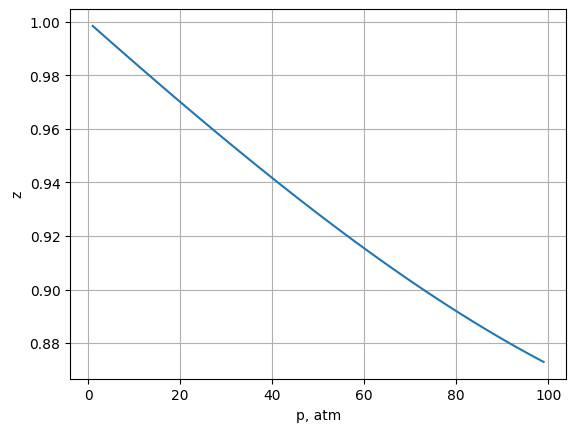

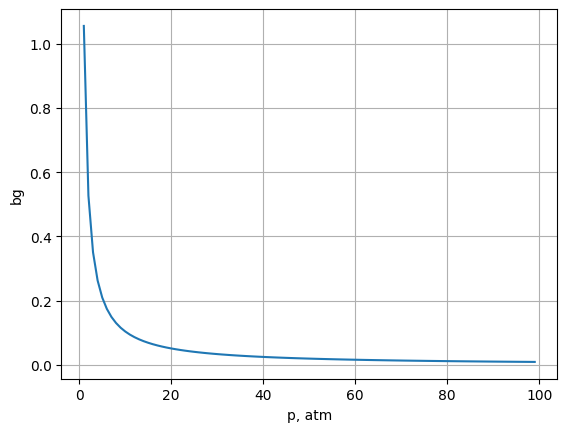

In [3]:
import pandas as pd

# Загрузка данных
df = pd.read_csv('hw2_data.csv', sep=';', index_col=0)
display(df)

student_name = "Слива Никита Владиславович"
row = df[df['student'] == student_name].iloc[0]

rho_c = row['rho_c, kg/m3']
xa = row['xa, mol. %'] / 100
xy = row['xy, mol. %'] / 100

fluid = Fluid(rho_c, xa, xy)

print("Параметры:")
print("rho_c =", rho_c)
print("xa =", xa)
print("xy =", xy)

P_test, T_test = 50, 310
z = fluid.get_Z(P_test, T_test)
bg = fluid.get_Bg(P_test, T_test)

print("Z =", z)
print("Bg =", bg)

fluid.plot_Z()
fluid.plot_Bg()